### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [184]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [185]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint
messages=[
    AIMessage(content=f"Please tell me how can I help",name="LLMModel")

]
messages.append(HumanMessage(content="I want to learn coading",name="Krish"))

messages.append(
    AIMessage(content=f"Which programing language you want to learn",name="LLMModel")

)
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Krish"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coading
================================== Ai Message ==================================
Name: LLMModel

Which programing language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [231]:
# from langchain_ollama import  ChatOllama,OllamaEmbeddings
# llm=ChatOllama(model="llama3.2:latest")
# from langchain_google_genai import ChatGoogleGenerativeAI
# llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
llm.invoke("hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 72, 'total_tokens': 103, 'completion_time': 0.035299252, 'prompt_time': 0.003719621, 'queue_time': 0.049776504, 'total_time': 0.039018873, 'completion_tokens_details': {'reasoning_tokens': 13}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd839-8f6c-7830-90f9-9479e65eedbb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 31, 'total_tokens': 103})

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [232]:
def add(a:int,b:int):
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b



In [233]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x00000187535FAB90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018758CE48D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [234]:
llm_with_tool=llm.bind_tools([add])
tool_call=llm_with_tool.invoke([HumanMessage(content="What is 2 plus 2",name="Krish")])

In [235]:
tool_call.tool_calls

[]

In [236]:
tool_call

AIMessage(content='2 plus 2 equals 4.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 148, 'total_tokens': 197, 'completion_time': 0.050636291, 'prompt_time': 0.008395342, 'queue_time': 0.050098808, 'total_time': 0.059031633, 'completion_tokens_details': {'reasoning_tokens': 32}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd839-9ccb-7762-8d80-fed1537ebbe7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 148, 'output_tokens': 49, 'total_tokens': 197})

### Using Messages as State

In [237]:
from typing_extensions import Annotated,TypedDict
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,SystemMessage,AnyMessage
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    message:list[AnyMessage]



#### Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [238]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    message:Annotated[list[AnyMessage],add_messages]
    name:str


#### Reducer

In [239]:
initial_messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
initial_messages.append(HumanMessage(content="I want to learn coading",name="Krish"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coading', additional_kwargs={}, response_metadata={}, name='Krish')]

In [240]:
ai_message=AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message


AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [241]:

### ^ Reducers add_messages is to append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='c12f683d-cca2-459d-8161-5d7cbdc4e172', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coading', additional_kwargs={}, response_metadata={}, name='Krish', id='c95d32fb-26dc-4f5c-9876-158fd0ee3fc6'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='67feadee-7a26-4632-8fbe-91dd47f7be44', tool_calls=[], invalid_tool_calls=[])]

In [242]:
def llm_tool(state:State):
    return {"message":[llm_with_tool.invoke(state["message"])]}


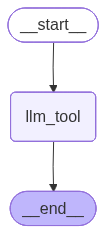

In [243]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)
builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)
final_graph=builder.compile()
display(Image(final_graph.get_graph().draw_mermaid_png()))


In [244]:

# ! invoke
messages=final_graph.invoke({"message":"what is 2 plus 2"})
for message in messages['message']:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (fc_d501b6cc-0df9-4ece-a379-c4583a48b388)
 Call ID: fc_d501b6cc-0df9-4ece-a379-c4583a48b388
  Args:
    a: 2
    b: 2


In [245]:
tools=[add]

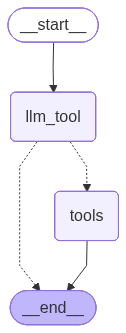

In [246]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder=StateGraph(State)
builder.add_node("llm_tool",llm_tool)

builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges("llm_tool",tools_condition)
builder.add_edge("tools",END)
final_graph=builder.compile()
display(Image(final_graph.get_graph().draw_mermaid_png()))

In [247]:
from langchain_core.messages import HumanMessage

messages = final_graph.invoke({
    "message": HumanMessage(content="What is 2 plus 2")
})

for msg in messages["message"]:
    msg.pretty_print()

ValueError: No messages found in input state to tool_edge: {'message': [HumanMessage(content='What is 2 plus 2', additional_kwargs={}, response_metadata={}, id='0dd7ece7-d119-4eac-a919-b1d667632fbf'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fc_1f31d35b-600a-4d44-8c4d-f6cfcc5d46a2', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 148, 'total_tokens': 195, 'completion_time': 0.055685833, 'prompt_time': 0.01297337, 'queue_time': 0.556150932, 'total_time': 0.068659203, 'completion_tokens_details': {'reasoning_tokens': 21}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_deb540145b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dd839-d250-7890-b676-abc8725b7060-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'fc_1f31d35b-600a-4d44-8c4d-f6cfcc5d46a2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metada

In [205]:
tools=[add]

In [206]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
builder=StateGraph(State)


## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()


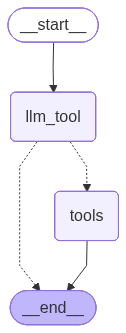

In [207]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [208]:
messages=graph_builder.invoke({"message":HumanMessage(content="what is 2 plus 2", name="Krish")})
for message in messages['message']:
    message.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=add{"a": 2, "b": 2}</function>'}}

In [209]:
messages=graph_builder.invoke({"message":HumanMessage(content="what is Machine Learning?", name="Krish")})
for message in messages['message']:
    message.pretty_print()

ValueError: No messages found in input state to tool_edge: {'message': [HumanMessage(content='what is Machine Learning?', additional_kwargs={}, response_metadata={}, name='Krish', id='2c567a79-d2d2-48da-a318-77a59489ded0'), AIMessage(content='Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It allows systems to learn from data, identify patterns, and make decisions or predictions based on that data.\n\nThere are several types of machine learning, including:\n\n1. Supervised learning: This type of learning involves training a model on labeled data, where the correct output is already known. The model learns to map inputs to outputs based on the labeled data.\n2. Unsupervised learning: This type of learning involves training a model on unlabeled data, where the model must find patterns or structure in the data on its own.\n3. Reinforcement learni

# Main

### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [210]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [211]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Krish"))

for message in messages:
    message.pretty_print()



================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [213]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke(messages)

In [ ]:
result.response_metadata

{'token_usage': {'completion_tokens': 446,
  'prompt_tokens': 75,
  'total_tokens': 521,
  'completion_time': 2.23,
  'prompt_time': 0.006678778,
  'queue_time': 0.242182835,
  'total_time': 2.236678778},
 'model_name': 'qwen-2.5-32b',
 'system_fingerprint': 'fp_35f92f8282',
 'finish_reason': 'stop',
 'logprobs': None}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [214]:
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [215]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000018758CAE490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018758CAC710>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [216]:
### Binding tool with llm

llm_with_tools=llm.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Krish")])

In [217]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'fc_4ddecc23-6865-402b-a3c5-6019b1465bcc',
  'type': 'tool_call'}]

### Using messages as state

In [218]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

#### Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [219]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### Reducers with add_messages

In [220]:
initial_messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish')]

In [221]:
ai_message=AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [222]:
### Reducers add_messages is to append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='d9d0afcd-72ad-4ab5-a247-3ec25acfa358', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish', id='5faba1ba-045d-429e-8595-618feaa184fe'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='f980ba52-5460-4b35-ba82-a4c48716f3b5', tool_calls=[], invalid_tool_calls=[])]

In [223]:
## chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

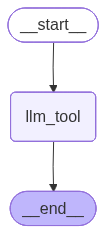

In [224]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [225]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (fc_be7087f3-5624-4bf6-9d31-7cc6144356dd)
 Call ID: fc_be7087f3-5624-4bf6-9d31-7cc6144356dd
  Args:
    a: 2
    b: 2


In [226]:
tools=[add]

In [227]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder=StateGraph(State)

## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()



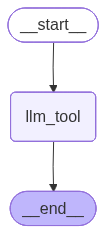

In [228]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [229]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (fc_8189b933-46b8-49fc-8805-47e352cf9c65)
 Call ID: fc_8189b933-46b8-49fc-8805-47e352cf9c65
  Args:
    a: 2
    b: 2


In [230]:
messages=graph.invoke({"messages":"What Machine Learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What Machine Learning
================================== Ai Message ==================================

**Machine Learning (ML)** is a branch of artificial intelligence that focuses on building systems that can learn from data, identify patterns, and make decisions with minimal human intervention. Instead of being explicitly programmed to perform a task, an ML model learns how to perform it by being exposed to examples.

---

## 1. Core Concepts

| Concept | What it Means | Example |
|---------|---------------|---------|
| **Training Data** | The dataset used to teach the model. | Images of cats and dogs for a classifier. |
| **Features** | Input variables that describe the data. | Pixel values in an image, word counts in a text. |
| **Labels** | Desired output or target values. | “cat” or “dog” in a classification task. |
| **Model** | The algorithm that learns from data. | A neural network, decision tre